In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
msp_table = pd.read_csv('/data/winfreyc/beer_project/samCoverageList_forMSPsampHeads.txt', sep='\t', index_col=0)

Text(0.5, 0, 'protein mean number of reads')

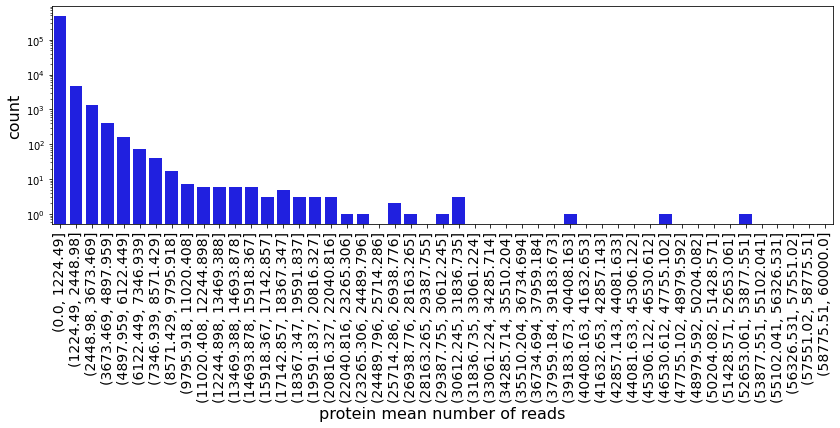

In [75]:
fig, ax = plt.subplots(figsize=(14,4))
cut_data = pd.cut(msp_table.mean(1), np.linspace(0, 6e4, 50)).value_counts().sort_index()
sns.barplot(y=cut_data.values, x=cut_data.index, color='blue')
ax.set_yscale('log')
plt.tick_params(rotation=90, axis='x', labelsize=14)
ax.set_ylabel('count', fontsize=16)
ax.set_xlabel('protein mean number of reads', fontsize=16)

In [47]:
from Bio import SeqIO

In [49]:
with open('/data/winfreyc/beer_project/allFebResults.fa', 'r') as handle:
    seq_lengths = pd.Series([(r.id, len(r.seq)) for r in SeqIO.parse(handle, 'fasta')])
    

In [54]:
seq_lengths = pd.Series(dict(seq_lengths.values))

In [77]:
seq_lengths

[CommStd_S36]k141_2578_1     327
[CommStd_S36]k141_19758_1    390
[CommStd_S36]k141_22335_1    255
[CommStd_S36]k141_18040_1    216
[CommStd_S36]k141_26630_1     60
                            ... 
[UO6-3_S52]k141_17958_1      369
[UO6-3_S52]k141_17959_1      309
[UO6-3_S52]k141_17960_1       90
[UO6-3_S52]k141_17960_2      183
[UO6-3_S52]k141_17961_1       69
Length: 1892696, dtype: int64

Text(0.5, 0, 'protein lengths')

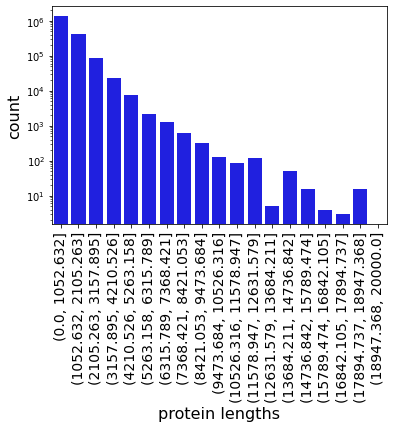

In [71]:
fig, ax = plt.subplots(figsize=(6,4))
cut_data = pd.cut(seq_lengths, np.linspace(0, 2e4, 20)).value_counts().sort_index()
sns.barplot(y=cut_data.values, x=cut_data.index, color='blue')
ax.set_yscale('log')
plt.tick_params(rotation=90, axis='x', labelsize=14)
ax.set_ylabel('count', fontsize=16)
ax.set_xlabel('protein lengths', fontsize=16)

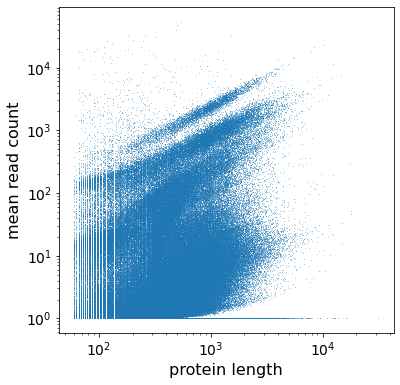

In [60]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=seq_lengths, y=msp_table.mean(1), linewidth=0, s=1, alpha=0.5)
ax.set_xlabel('protein length', fontsize=16)
ax.set_ylabel('mean read count', fontsize=16)
ax.set_yscale('log')
ax.set_xscale('log')
plt.tick_params(labelsize=14)

In [73]:
msp_table.mean(1).sort_values()

[CommStd_S36]k141_0_1            1.000000
[HO3-3_S47]k141_9148_1           1.000000
[HO3-3_S47]k141_9150_1           1.000000
[HO3-3_S47]k141_9151_1           1.000000
[HO3-3_S47]k141_9160_1           1.000000
                                 ...     
[CommStd_S36]k141_19072_2    31600.340426
[HO5-3_S5]k141_14000_1       31759.063830
[UC2_S23]k141_12579_3        40001.063830
[HO2-3_S40]k141_3136_1       47398.361702
[UI4-1_S38]k141_1335_1       53616.978723
Length: 481634, dtype: float64

In [76]:
msp_table.head() #shape

,HI1-1,HI1-3,HI2-1,HI2-3,HI3-1,HI3-3,HI4-1,HI4-3,HI5-1,HI5-3,...,UO2-1,UO2-3,UO3-1,UO3-3,UO4-1,UO4-3,UO5-1,UO5-3,UO6-1,UO6-3
[CommStd_S36]k141_0_1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[CommStd_S36]k141_10000_1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[CommStd_S36]k141_10001_1,24,1,14,14,1,1,11,18,1,1,...,21,10,25,14,19,1,1,1,1,6
[CommStd_S36]k141_10002_1,364,179,189,198,209,123,318,236,65,364,...,554,208,555,498,532,409,379,131,502,194
[CommStd_S36]k141_10003_1,2814,1012,1381,1280,1191,945,2284,754,790,791,...,664,274,577,503,902,226,445,238,689,332


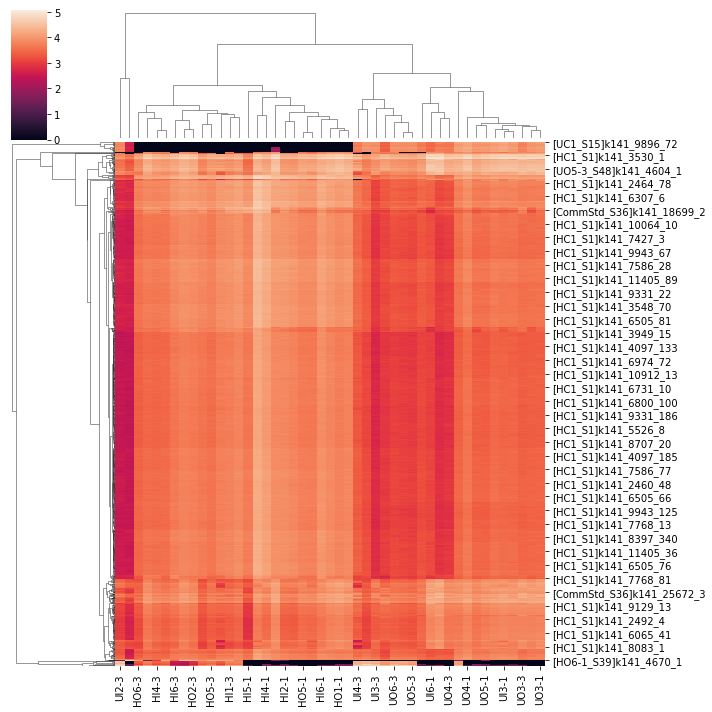

In [83]:
sns.clustermap(msp_table.reindex(index=msp_table.mean(1).sort_values(ascending=False).index).iloc[:1000, :].apply(np.log10))

### Filtering proteins to partial=00

In [85]:
import glob

In [93]:
# get partial = 00 sequences for each sample
protein_files = glob.glob('/data/winfreyc/beer_project/*/MegaResults/my.proteins.faa')
all_complete_records = []
for p in protein_files:
    sample_name = p.split('/')[-3]
    print(p, sample_name)
    with open(p) as handle:
        records = [r for r in SeqIO.parse(p, 'fasta')]
        all_complete_records += [f'[{sample_name}]{r.id}' for r in records if 'partial=00' in r.description]

/data/winfreyc/beer_project/CommStd_S36/MegaResults/my.proteins.faa CommStd_S36
/data/winfreyc/beer_project/ExtB1_S43/MegaResults/my.proteins.faa ExtB1_S43
/data/winfreyc/beer_project/HC1_S1/MegaResults/my.proteins.faa HC1_S1
/data/winfreyc/beer_project/HI1-1_S46/MegaResults/my.proteins.faa HI1-1_S46
/data/winfreyc/beer_project/HI1-3_S6/MegaResults/my.proteins.faa HI1-3_S6
/data/winfreyc/beer_project/HI2-1_S50/MegaResults/my.proteins.faa HI2-1_S50
/data/winfreyc/beer_project/HI2-3_S12/MegaResults/my.proteins.faa HI2-3_S12
/data/winfreyc/beer_project/HI3-1_S4/MegaResults/my.proteins.faa HI3-1_S4
/data/winfreyc/beer_project/HI3-3_S20/MegaResults/my.proteins.faa HI3-3_S20
/data/winfreyc/beer_project/HI4-1_S10/MegaResults/my.proteins.faa HI4-1_S10
/data/winfreyc/beer_project/HI4-3_S28/MegaResults/my.proteins.faa HI4-3_S28
/data/winfreyc/beer_project/HI5-1_S18/MegaResults/my.proteins.faa HI5-1_S18
/data/winfreyc/beer_project/HI5-3_S35/MegaResults/my.proteins.faa HI5-3_S35
/data/winfreyc/bee

In [99]:
subset_msp_table_index = set(all_complete_records).intersection(set(msp_table.index))
len(subset_msp_table_index)

98287

In [100]:
subset_msp_table = msp_table.reindex(index=subset_msp_table_index)

In [111]:
subset_msp_table.loc[(subset_msp_table.mean(1) >  1), :].replace({1:0}).to_csv('/data/mhoffert/tools/MSPminer_1_1_3/test_table.tsv', sep='\t')

In [109]:
subset_msp_table.

,HI1-1,HI1-3,HI2-1,HI2-3,HI3-1,HI3-3,HI4-1,HI4-3,HI5-1,HI5-3,...,UO2-1,UO2-3,UO3-1,UO3-3,UO4-1,UO4-3,UO5-1,UO5-3,UO6-1,UO6-3
[UC1_S15]k141_13227_19,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[CommStd_S36]k141_21720_552,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[HO5-3_S5]k141_12881_2,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[UC1_S15]k141_14656_40,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[CommStd_S36]k141_12842_280,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[CommStd_S36]k141_5841_2,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
[UI1-3_S49]k141_8261_80,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,14,1,1,1,268
[HI4-3_S28]k141_1158_28,1,1,1,1,1,1,1,5011,1,5202,...,1,1,1,1,1,1,1,1,1,1
[HC1_S1]k141_11893_2,1,1,1,1,1,1,1,1,1,29,...,1,1,1,1,1,1,1,1,1,1


In [114]:
msp_table.columns.values

array(['HI1-1', 'HI1-3', 'HI2-1', 'HI2-3', 'HI3-1', 'HI3-3', 'HI4-1',
       'HI4-3', 'HI5-1', 'HI5-3', 'HI6-1', 'HI6-3', 'HO1-1', 'HO1-3',
       'HO2-1', 'HO2-3', 'HO3-1', 'HO3-3', 'HO4-1', 'HO4-3', 'HO5-1',
       'HO5-3', 'HO6-1', 'HO6-3', 'UI1-1', 'UI1-3', 'UI2-1', 'UI2-3',
       'UI3-1', 'UI3-3', 'UI4-1', 'UI4-3', 'UI5-3', 'UI6-1', 'UI6-3',
       'UO1-1', 'UO1-3', 'UO2-1', 'UO2-3', 'UO3-1', 'UO3-3', 'UO4-1',
       'UO4-3', 'UO5-1', 'UO5-3', 'UO6-1', 'UO6-3'], dtype=object)

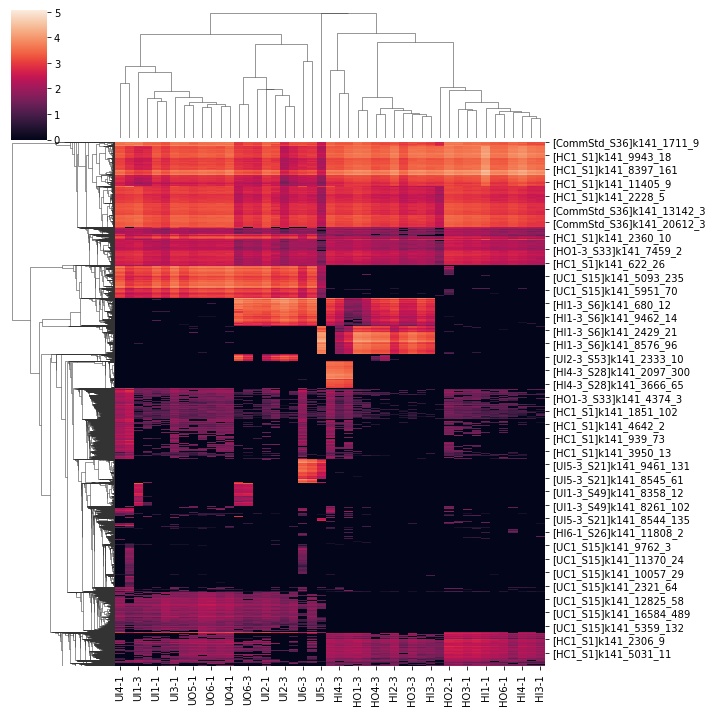

In [116]:
sns.clustermap(subset_msp_table.loc[(subset_msp_table.mean(1) >  1), :].apply(np.log10))